# Three-Dimensional Lattice Geometry

This notebook constructs a simple-cubic direct lattice, its Wigner-Seitz cell, reciprocal lattice, first Brillouin zone, and a high-symmetry wavevector path.

```mermaid
flowchart TD
    D["DirectLattice3D"] --> W["WignerSeitzCell3D"]
    D --> R["ReciprocalLattice3D"]
    R --> B["FirstBrillouinZone3D"]
    B --> K["KPointPath3D"]
```

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

from physkit.periodic.lattice.base import (
    FloatArray,
    IntArray,
)
from physkit.periodic import (
    DirectLattice,
    DirectLattice3D,
    FirstBrillouinZone3D,
    KPointPath3D,
    ReciprocalLattice3D,
    WignerSeitzCell3D,
)

## Direct lattice

The simple-cubic primitive basis is

$$A=aI_3.$$

Direct-lattice vectors are $\mathbf R_{\mathbf n}=A\mathbf n$.

In [2]:
a = 1.0
a1 = np.array([a, 0.0, 0.0])
a2 = np.array([0.0, a, 0.0])
a3 = np.array([0.0, 0.0, a])

direct_lattice = DirectLattice3D(
    a1=a1,
    a2=a2,
    a3=a3,
)

assert isinstance(direct_lattice, DirectLattice)

print(f"direct_lattice.a1:{direct_lattice.a1}")
print(f"direct_lattice.a1:{direct_lattice.a2}")
print(f"direct_lattice.a1:{direct_lattice.a3}")
assert np.allclose(direct_lattice.a1, a1)
assert np.allclose(direct_lattice.a2, a2)
assert np.allclose(direct_lattice.a3, a3)

print("Primitive basis A:")
print(direct_lattice.A)
print("Primitive-cell volume:", direct_lattice.measure)

direct_lattice.a1:[1. 0. 0.]
direct_lattice.a1:[0. 1. 0.]
direct_lattice.a1:[0. 0. 1.]
Primitive basis A:
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]
Primitive-cell volume: 1.0


In [3]:
shell = 1
direct_modes = np.array([
    (m1, m2, m3)
    for m1 in range(-shell, shell + 1)
    for m2 in range(-shell, shell + 1)
    for m3 in range(-shell, shell + 1)
], dtype=np.int64)
direct_points = direct_lattice.vector(direct_modes)

## Wigner-Seitz Cells, Voronoi Cells, and Triangulation

### Direct Bravais Lattice
Let the direct Bravais lattice be
$$
\mathcal{R}
= \left\{
  \mathbf{R}_{\mathbf{n}}
= \sum_{\mu=1}^{d}
  n_{\mu}\mathbf{a}_{\mu}
\;:\;
\mathbf{n}\in\mathbb{Z}^{d}
\right\},
$$

where $\mathbf{a}_1,\ldots,\mathbf{a}_d$ are the direct primitive vectors.

Every direct-lattice vector is an element

$$
\mathbf{R}\in\mathcal{R}.
$$

### Wigner-Seitz Cell

The Wigner-Seitz cell associated with the lattice point at the origin is the set of position vectors $\mathbf{r}\in\mathbb{R}^{d}$ that are at least as close to the origin as to every other lattice point:

$$
\mathcal{W}(\mathcal{R})
=
\left\{
\mathbf{r}\in\mathbb{R}^{d}
:
\lVert\mathbf{r}\rVert
\leq
\lVert\mathbf{r}-\mathbf{R}\rVert
\quad
\forall\,
\mathbf{R}\in
\mathcal{R}\setminus\{\mathbf{0}\}
\right\}.
$$

The condition associated with $\mathbf{R}=\mathbf{0}$ is automatically satisfied. The definition may therefore be written as

$$
\mathcal{W}(\mathcal{R})
=
\left\{
\mathbf{r}\in\mathbb{R}^{d}
:
\lVert\mathbf{r}\rVert
\leq
\lVert\mathbf{r}-\mathbf{R}\rVert
\quad
\text{for every }
\mathbf{R}\in
\mathcal{R}\setminus\{\mathbf{0}\}
\right\}
$$

We start with the analysis of the inequality

$$\begin{gather}
\lVert\mathbf{r}\rVert
    \leq\lVert\mathbf{r}-\mathbf{R}\rVert \\
\lVert\mathbf{r}\rVert^{2}
    \leq \lVert\mathbf{r}-\mathbf{R}\rVert^{2}
    =\lVert\mathbf{r}\rVert^{2}
        - 2\mathbf{R}\cdot\mathbf{r}
        + \lVert\mathbf{R}\rVert^{2} \\
2\mathbf{R}\cdot\mathbf{r}
\leq
\lVert\mathbf{R}\rVert^{2},
\end{gather}$$

or equivalently,

$$
\mathbf{R}\cdot\mathbf{r}
\leq
\frac{\lVert\mathbf{R}\rVert^{2}}{2}.
$$

Each nonzero lattice vector $\mathbf{R}\in\mathcal{R}$ defines the closed half-space

$$
\mathcal{H}_{\mathbf{R}}
=
\left\{
\mathbf{r}\in\mathbb{R}^{d}
:
\mathbf{R}\cdot\mathbf{r}
\leq
\frac{\lVert\mathbf{R}\rVert^{2}}{2}
\right\}.
$$

The Wigner-Seitz cell is the intersection of all such half-spaces:

$$
\boxed{
\mathcal{W}(\mathcal{R})
=
\bigcap_{
\mathbf{R}\in
\mathcal{R}\setminus\{\mathbf{0}\}
}
\mathcal{H}_{\mathbf{R}}
}.
$$


### Voronoi Cell
Let an arbitrary set of sites be
$$
\mathcal{P}
  = \left\{\mathbf{p}_i\right\}
    \subset\mathbb{R}^{d}.
$$
The Voronoi cell associated with the site $\mathbf{p}_i\in\mathcal{P}$ is

$$
\mathcal{V}_i(\mathcal{P})
  = \left\{
    \mathbf{r}\in\mathbb{R}^{d}
    :
    \lVert\mathbf{r}-\mathbf{p}_i\rVert
    \leq
    \lVert\mathbf{r}-\mathbf{p}_j\rVert
    \quad
    \forall
    \mathbf{p}_j\in\mathcal{P}
  \right\}.
$$

Taking the sites to be the Bravais-lattice points,

$$
\mathcal{P}
=
\mathcal{R},
$$

and choosing the lattice point at the origin gives

$$
\boxed{
\mathcal{W}(\mathcal{R})
=
\mathcal{V}_{\mathbf{0}}(\mathcal{R})
}.
$$

Thus:

- A **Voronoi cell** is defined for a general set of sites.
- A **Wigner-Seitz cell** is the Voronoi cell of a Bravais-lattice point.
- The **first Brillouin zone** is the Wigner-Seitz cell of the reciprocal lattice.

In [4]:
wigner_seitz_cell = WignerSeitzCell3D(
    lattice=direct_lattice,
    neighbor_shell=2,
)

print("Number of Wigner-Seitz vertices:", len(wigner_seitz_cell.vertices))
print("Wigner-Seitz volume:", wigner_seitz_cell.measure)

assert np.isclose(
    wigner_seitz_cell.measure,
    direct_lattice.measure,
)

Number of Wigner-Seitz vertices: 8
Wigner-Seitz volume: 1.0


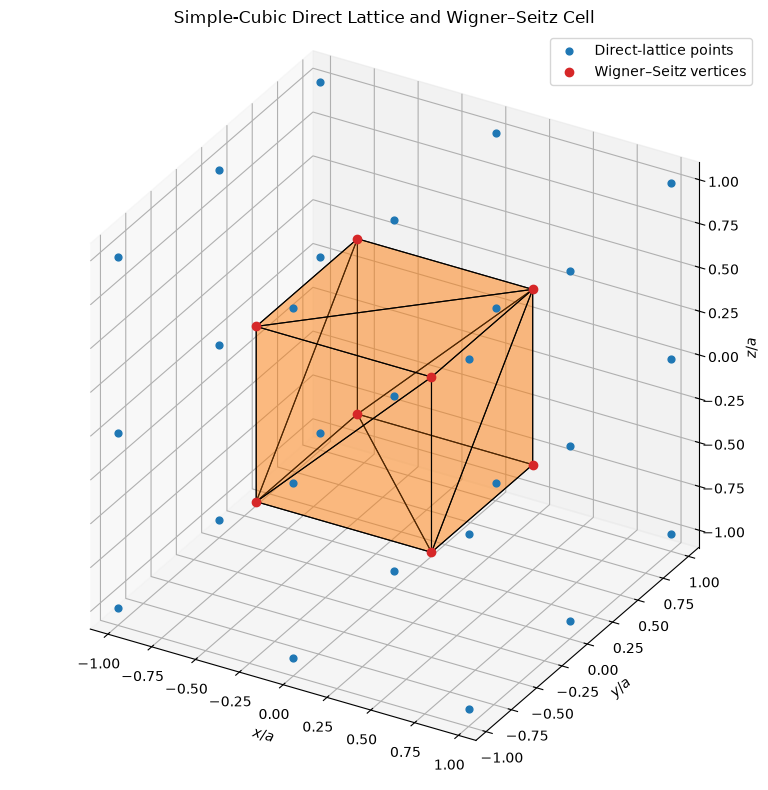

Direct-lattice measure: 1.0
Wigner–Seitz measure: 1.0
Number of vertices: 8
Vertices:
[[-0.5 -0.5 -0.5]
 [ 0.5 -0.5 -0.5]
 [-0.5 -0.5  0.5]
 [ 0.5 -0.5  0.5]
 [ 0.5  0.5 -0.5]
 [-0.5  0.5 -0.5]
 [ 0.5  0.5  0.5]
 [-0.5  0.5  0.5]]


In [5]:
# Scale both the lattice points and Wigner–Seitz vertices by the same
# reference length because the axes are labelled x/a, y/a, and z/a.
a = direct_lattice.measure ** (1.0 / 3.0)

scaled_direct_points = direct_points / a
scaled_ws_vertices = wigner_seitz_cell.vertices / a
ws_triangles = scaled_ws_vertices[wigner_seitz_cell.faces]

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(
    111,
    projection="3d",
)

# Orthographic projection reduces perspective distortion and makes the
# cubic geometry easier to recognize.
ax.set_proj_type("ortho")

# Plot direct-lattice points.
ax.scatter(
    scaled_direct_points[:, 0],
    scaled_direct_points[:, 1],
    scaled_direct_points[:, 2],
    s=24,
    color="tab:blue",
    depthshade=False,
    label="Direct-lattice points",
)

# Plot the triangulated boundary of the Wigner–Seitz polyhedron.
wigner_seitz_surface = Poly3DCollection(
    ws_triangles,
    facecolor="tab:orange",
    edgecolor="black",
    linewidth=0.8,
    alpha=0.30,
)

ax.add_collection3d(
    wigner_seitz_surface,
)

# Plot the Wigner–Seitz vertices explicitly.
ax.scatter(
    scaled_ws_vertices[:, 0],
    scaled_ws_vertices[:, 1],
    scaled_ws_vertices[:, 2],
    s=36,
    color="tab:red",
    depthshade=False,
    label="Wigner–Seitz vertices",
)

# Compute one common limit from everything displayed.
all_points = np.vstack(
    (
        scaled_direct_points,
        scaled_ws_vertices,
    )
)

coordinate_limit = 1.1 * np.max(
    np.abs(all_points)
)

ax.set_xlim(
    -coordinate_limit,
    coordinate_limit,
)
ax.set_ylim(
    -coordinate_limit,
    coordinate_limit,
)
ax.set_zlim(
    -coordinate_limit,
    coordinate_limit,
)

# Equal box dimensions now correspond to equal coordinate limits.
ax.set_box_aspect((1.0, 1.0, 1.0))

ax.set_xlabel(r"$x/a$")
ax.set_ylabel(r"$y/a$")
ax.set_zlabel(r"$z/a$")
ax.set_title(
    "Simple-Cubic Direct Lattice and Wigner–Seitz Cell"
)
ax.legend()

plt.tight_layout()
plt.show()


expected_measure = direct_lattice.measure

print("Direct-lattice measure:", expected_measure)
print("Wigner–Seitz measure:", wigner_seitz_cell.measure)
print("Number of vertices:", len(wigner_seitz_cell.vertices))
print("Vertices:")
print(wigner_seitz_cell.vertices)

assert np.isclose(
    wigner_seitz_cell.measure,
    expected_measure,
)

assert len(wigner_seitz_cell.vertices) == 8

### Why Triangles Appear in Three-Dimensional Plots

The triangles appearing in a three-dimensional Wigner-Seitz plot are generally not physical boundaries of the cell. They arise from the computational representation returned by a convex-hull algorithm.

For example, the Wigner-Seitz cell of a simple-cubic lattice is a cube with six square faces. However, `scipy.spatial.ConvexHull` represents the boundary using simplicial facets.

In three dimensions, a simplicial facet is a triangle. Each square face is therefore divided into two triangles:

$$
6\text{ square faces}
\longrightarrow
12\text{ triangular facets}.
$$

The diagonal dividing a square into two triangles is not a Wigner-Seitz boundary. It is only part of the surface triangulation used to represent and render the polyhedron.

### Voronoi and Delaunay Structures

The geometric dual of a Voronoi diagram is the **Delaunay decomposition**.

- Voronoi cells describe the regions closest to individual sites.
- Delaunay edges connect sites whose Voronoi cells share a boundary.
- In two dimensions, generic Delaunay cells are triangles.
- In three dimensions, generic Delaunay cells are tetrahedra.

The Delaunay triangulation is geometrically meaningful. It must not be confused with the triangular surface mesh returned by `ConvexHull`.

| Object | Meaning of its triangles |
| --- | --- |
| `ConvexHull.simplices` | Triangular mesh representing a polyhedron boundary |
| Delaunay triangulation | Geometric structure dual to a Voronoi diagram |
| Wigner-Seitz cell | Voronoi region of a lattice point; not inherently triangular |

### Example: Triangular Lattice

For a two-dimensional triangular Bravais lattice,

$$
\text{triangular lattice}
\quad
\longrightarrow
\quad
\text{hexagonal Wigner-Seitz cell}.
$$

The Delaunay cells are triangles, while the dual Voronoi cells are hexagons:

$$
\boxed{
\text{triangular Delaunay cells}
\quad
\longleftrightarrow
\quad
\text{hexagonal Voronoi cells}
}.
$$

For a simple-cubic lattice, the physical Wigner-Seitz cell is a cube. Any triangles drawn across its square faces belong to the computational surface mesh, not to the physical cell boundary.

In [6]:
import matplotlib.pyplot as plt
import numpy as np

from matplotlib.collections import PolyCollection
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from numpy.typing import NDArray
from scipy.spatial import ConvexHull

from physkit.periodic.lattice.base import FloatArray
def construct_polygon_faces(
    vertices: FloatArray,
    *,
    tolerance: float = 1.0e-10,
) -> list[FloatArray]:
    """
    Construct ordered polygonal faces of a convex polyhedron.

    Parameters
    ----------
    vertices:
        Convex-polyhedron vertices with shape ``(N, 3)``.
    tolerance:
        Absolute tolerance used to identify vertices lying in the same
        face plane.

    Returns
    -------
    list[FloatArray]
        Ordered vertices for each polygonal face.
    """
    hull = ConvexHull(vertices)

    # Qhull triangulates polygonal faces. Coplanar triangles have the same
    # plane equation, so rounding removes duplicate equations.
    plane_equations = np.unique(
        np.round(
            hull.equations,
            decimals=10,
        ),
        axis=0,
    )

    polygon_faces: list[FloatArray] = []

    for equation in plane_equations:
        normal = equation[:3]
        offset = equation[3]

        # Identify every polyhedron vertex lying in this face plane.
        signed_distance = vertices @ normal + offset
        face_vertices = vertices[
            np.abs(signed_distance) <= tolerance
        ]

        # Compute the center of the polygon.
        face_center = np.mean(
            face_vertices,
            axis=0,
        )

        # Construct an orthonormal coordinate system within the face plane.
        first_direction = face_vertices[0] - face_center
        first_direction /= np.linalg.norm(first_direction)

        second_direction = np.cross(
            normal,
            first_direction,
        )
        second_direction /= np.linalg.norm(second_direction)

        # Sort the face vertices by polar angle around the face center.
        relative_vertices = face_vertices - face_center
        angles = np.arctan2(
            relative_vertices @ second_direction,
            relative_vertices @ first_direction,
        )

        ordered_vertices = face_vertices[
            np.argsort(angles)
        ]

        polygon_faces.append(
            ordered_vertices
        )

    return polygon_faces

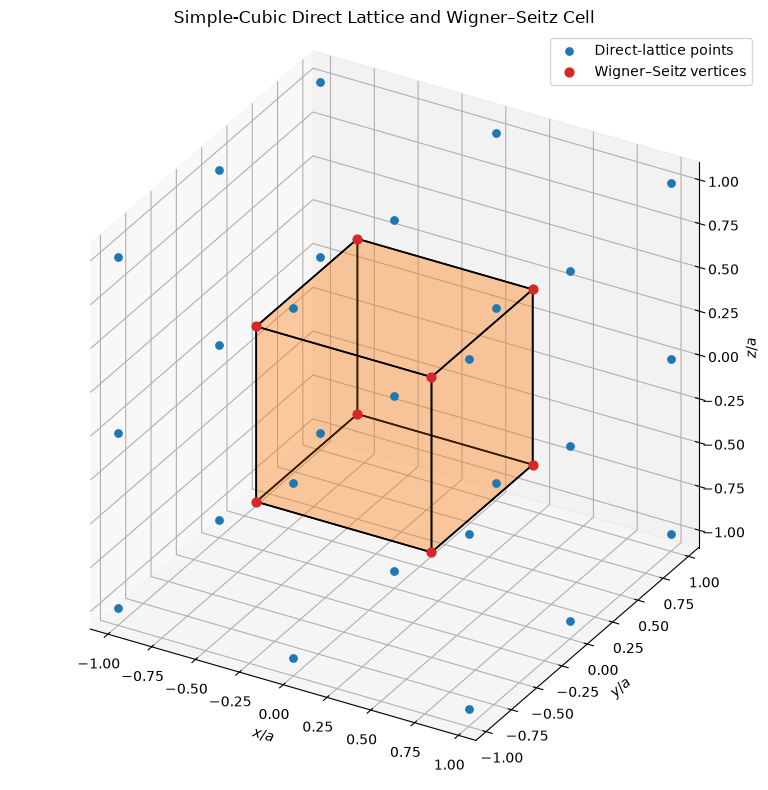

In [7]:
a = direct_lattice.measure ** (1.0 / 3.0)

scaled_direct_points = direct_points / a
scaled_ws_vertices = wigner_seitz_cell.vertices / a

ws_polygon_faces = construct_polygon_faces(
    scaled_ws_vertices,
)

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(
    111,
    projection="3d",
)

ax.set_proj_type("ortho")

ax.scatter(
    scaled_direct_points[:, 0],
    scaled_direct_points[:, 1],
    scaled_direct_points[:, 2],
    s=28,
    color="tab:blue",
    depthshade=False,
    label="Direct-lattice points",
)

# Each item is now one complete polygonal face. For the simple-cubic
# Wigner–Seitz cell, these are six squares rather than twelve triangles.
wigner_seitz_surface = Poly3DCollection(
    ws_polygon_faces,
    facecolor="tab:orange",
    edgecolor="black",
    linewidth=1.2,
    alpha=0.22,
)

ax.add_collection3d(
    wigner_seitz_surface,
)

ax.scatter(
    scaled_ws_vertices[:, 0],
    scaled_ws_vertices[:, 1],
    scaled_ws_vertices[:, 2],
    s=40,
    color="tab:red",
    depthshade=False,
    label="Wigner–Seitz vertices",
)

ax.set_xlim(-1.1, 1.1)
ax.set_ylim(-1.1, 1.1)
ax.set_zlim(-1.1, 1.1)
ax.set_box_aspect((1.0, 1.0, 1.0))

ax.set_xlabel(r"$x/a$")
ax.set_ylabel(r"$y/a$")
ax.set_zlabel(r"$z/a$")
ax.set_title(
    "Simple-Cubic Direct Lattice and Wigner–Seitz Cell"
)
ax.legend()

plt.tight_layout()
plt.show()

## Reciprocal lattice

The reciprocal primitive basis is

$$B=2\pi A^{-\mathsf T},$$

and satisfies $A^{\mathsf T}B=2\pi I_3$.

In [12]:
reciprocal_lattice = ReciprocalLattice3D.from_direct_lattice(
    direct_lattice=direct_lattice,
)

A = direct_lattice.A
B = reciprocal_lattice.B

print("Reciprocal primitive basis B:")
print(B)

print("A^T B:")
print(A.T @ B)

# Verify the defining relation between the direct and reciprocal
# primitive-basis matrices:
#     A^T B = 2π I.
assert np.allclose(A.T @ B, 2.0 * np.pi * np.eye(3))
assert np.allclose(B[:,0], reciprocal_lattice.b1)
assert np.allclose(B[:,1], reciprocal_lattice.b2)
assert np.allclose(B[:,2], reciprocal_lattice.b3)

Reciprocal primitive basis B:
[[6.28318531 0.         0.        ]
 [0.         6.28318531 0.        ]
 [0.         0.         6.28318531]]
A^T B:
[[6.28318531 0.         0.        ]
 [0.         6.28318531 0.        ]
 [0.         0.         6.28318531]]


## First Brillouin zone

The first Brillouin zone is the Wigner-Seitz cell of the reciprocal lattice. Its volume is

$$
\Omega_{\mathrm{BZ}}
  =\frac{(2\pi)^3}{\Omega}
$$

In [ ]:
first_brillouin_zone = FirstBrillouinZone3D(
    reciprocal_lattice=reciprocal_lattice,
    neighbor_shell=2,
)

expected_zone_volume = (
    (2.0 * np.pi) ** 3
    / direct_lattice.primitive_cell_measure
)

print("Number of zone vertices:", len(first_brillouin_zone.vertices))
print("Calculated zone volume:", first_brillouin_zone.measure)
print("Expected zone volume:", expected_zone_volume)

assert np.isclose(first_brillouin_zone.measure, expected_zone_volume)

## High-symmetry path 
$\Gamma\to X\to M\to R\to\Gamma$

For the simple-cubic Brillouin zone, using $b=2\pi/a$,

$$\begin{gather}
  \Gamma=(0,0,0),\\
  X=\left( \frac{b}{2}, 0,           0\right),\\
  M=\left( \frac{b}{2}, \frac{b}{2}, 0 \right),\\
  R=\left( \frac{b}{2}, \frac{b}{2}, \frac{b}{2}\right)
\end{gather}$$

In [ ]:
b = reciprocal_lattice.b1[0]
Gamma = np.array([0.0, 0.0, 0.0])
X = np.array([0.5 * b, 0.0, 0.0])
M = np.array([0.5 * b, 0.5 * b, 0.0])
R = np.array([0.5 * b, 0.5 * b, 0.5 * b])

k_path = KPointPath3D(
    nodes=np.array([Gamma, X, M, R, Gamma]),
    labels=(r"$\Gamma$", r"$X$", r"$M$", r"$R$", r"$\Gamma$"),
    points_per_segment=51,
)

print("Number of path points:", k_path.size)
print("Node distances:", k_path.node_distances)

In [ ]:
bz_triangles = first_brillouin_zone.vertices[first_brillouin_zone.faces]
reciprocal_points = reciprocal_lattice.vector(direct_modes)

fig = plt.figure(figsize=(9, 8))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(reciprocal_points[:, 0], reciprocal_points[:, 1], reciprocal_points[:, 2], s=22, color="tab:green", alpha=0.45)
ax.add_collection3d(Poly3DCollection(
    bz_triangles,
    facecolor="tab:purple",
    edgecolor="black",
    alpha=0.12,
) )
ax.plot(k_path.values[:, 0], k_path.values[:, 1], k_path.values[:, 2], color="tab:red", linewidth=2.5)
ax.scatter(k_path.nodes[:, 0], k_path.nodes[:, 1], k_path.nodes[:, 2], s=55, color="black")
for point, label in zip(k_path.nodes, k_path.labels):
    ax.text(point[0], point[1], point[2], label)
ax.set_xlabel(r"$k_x$")
ax.set_ylabel(r"$k_y$")
ax.set_zlabel(r"$k_z$")
ax.set_title("Reciprocal Lattice, First Brillouin Zone, and $k$-Path")
ax.set_box_aspect((1, 1, 1))
plt.tight_layout()
plt.show()

## Summary

The same construction applies in three dimensions: the direct basis determines the reciprocal basis; the Wigner-Seitz construction produces the primitive direct cell and first Brillouin zone; and a path samples selected symmetry directions through reciprocal space.